In [258]:
# ▶ pd.set option
import json
import numpy as np
import pandas as pd 
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)  

# ▶ Data read
df = pd.read_csv("data/data.csv")
df.head()

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8,0,1,21,0,5.10000,35,2,6,1,1
1,9,0,1,42,0,4.95000,57,3,6,1,1
2,12,0,0,1,0,6.67000,19,3,6,1,0
3,12,0,0,4,0,4.00000,22,3,6,0,0
4,12,0,0,17,0,7.50000,35,3,6,0,1


In [259]:
meta = pd.read_csv("data/meta.csv")
meta.head()


,value,SOUTH,SEX,UNION,RACE,OCCUPATION,SECTOR,MARR
0,0,Person lives elsewhere,Male,Not union member,NaN,NaN,Other,Unmarried
1,1,Person lives in South,Female,Union member,Other,Management,Manufacturing,Married
2,2,NaN,NaN,NaN,Hispanic,Sales,Construction,NaN
3,3,NaN,NaN,NaN,White,Clerical,NaN,NaN
4,4,NaN,NaN,NaN,NaN,Service,NaN,NaN


In [260]:
df.shape

(534, 11)

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EDUCATION   534 non-null    int64  
 1   SOUTH       534 non-null    int64  
 2   SEX         534 non-null    int64  
 3   EXPERIENCE  534 non-null    int64  
 4   UNION       534 non-null    int64  
 5   WAGE        534 non-null    float64
 6   AGE         534 non-null    int64  
 7   RACE        534 non-null    int64  
 8   OCCUPATION  534 non-null    int64  
 9   SECTOR      534 non-null    int64  
 10  MARR        534 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 46.0 KB


In [262]:
print(df.isnull().sum())

EDUCATION     0
SOUTH         0
SEX           0
EXPERIENCE    0
UNION         0
WAGE          0
AGE           0
RACE          0
OCCUPATION    0
SECTOR        0
MARR          0
dtype: int64


In [263]:
df.duplicated().value_counts()

False    534
Name: count, dtype: int64

In [264]:
list_of_df = [] # empty list
 
for i in df.columns: # each column in df.columns
    loop_df = pd.DataFrame({'val' : [i], # 'val' is ['column_name']
                            'zero_cnt': df[df[i] == 0][i].count()})
    list_of_df.append(loop_df)
    
df_merge = pd.concat(list_of_df).reset_index(drop=True)
df_merge['zero_ratio'] = df_merge['zero_cnt'] / len(df) 
df_merge.sort_values(by=['zero_ratio'], ascending=False)
    

,val,zero_cnt,zero_ratio
4,UNION,438,0.82022
9,SECTOR,411,0.76966
1,SOUTH,378,0.70787
2,SEX,289,0.54120
10,MARR,184,0.34457
3,EXPERIENCE,11,0.02060
0,EDUCATION,0,0.00000
5,WAGE,0,0.00000
6,AGE,0,0.00000
7,RACE,0,0.00000


In [265]:
df.shape

(534, 11)

In [266]:
df.head()

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8,0,1,21,0,5.10000,35,2,6,1,1
1,9,0,1,42,0,4.95000,57,3,6,1,1
2,12,0,0,1,0,6.67000,19,3,6,1,0
3,12,0,0,4,0,4.00000,22,3,6,0,0
4,12,0,0,17,0,7.50000,35,3,6,0,1


In [267]:
import numpy as np
import pandas as pd

numerical_list =[]
categorical_list= []

for i in df.columns:
    if df[i].dtypes == 'O': # if type is object
        categorical_list.append(i)
    else:
        numerical_list.append(i)
        
print("numerical_list:", numerical_list)
print("categorical_list:", categorical_list)
        


numerical_list: ['EDUCATION', 'SOUTH', 'SEX', 'EXPERIENCE', 'UNION', 'WAGE', 'AGE', 'RACE', 'OCCUPATION', 'SECTOR', 'MARR']
categorical_list: []


In [268]:
for i in numerical_list:
    print(i, ":", df[i].nunique())

EDUCATION : 17
SOUTH : 2
SEX : 2
EXPERIENCE : 52
UNION : 2
WAGE : 238
AGE : 47
RACE : 3
OCCUPATION : 6
SECTOR : 3
MARR : 2


In [269]:
# column values are numbers but they are not numerical. They are categorical.
list_of_df = []

for i in numerical_list:
    loop_df = pd.DataFrame({'val' :[i],
                            'nunique':df[i].nunique()})
    list_of_df.append(loop_df)
    
df_merge = pd.concat(list_of_df).reset_index(drop=True)
df_merge.sort_values(by=['nunique'], ascending=False)

,val,nunique
5,WAGE,238
3,EXPERIENCE,52
6,AGE,47
0,EDUCATION,17
8,OCCUPATION,6
7,RACE,3
9,SECTOR,3
1,SOUTH,2
2,SEX,2
4,UNION,2


In [270]:
meta

,value,SOUTH,SEX,UNION,RACE,OCCUPATION,SECTOR,MARR
0,0,Person lives elsewhere,Male,Not union member,NaN,NaN,Other,Unmarried
1,1,Person lives in South,Female,Union member,Other,Management,Manufacturing,Married
2,2,NaN,NaN,NaN,Hispanic,Sales,Construction,NaN
3,3,NaN,NaN,NaN,White,Clerical,NaN,NaN
4,4,NaN,NaN,NaN,NaN,Service,NaN,NaN
5,5,NaN,NaN,NaN,NaN,Professional,NaN,NaN
6,6,NaN,NaN,NaN,NaN,Other,NaN,NaN


In [271]:
meta.columns[1:]

Index(['SOUTH', 'SEX', 'UNION', 'RACE', 'OCCUPATION', 'SECTOR', 'MARR'], dtype='object')

In [272]:
categorical_list = meta.columns[1:]
print(categorical_list)


Index(['SOUTH', 'SEX', 'UNION', 'RACE', 'OCCUPATION', 'SECTOR', 'MARR'], dtype='object')


In [273]:
for i in categorical_list:
    numerical_list.remove(i)
print(numerical_list)
    

['EDUCATION', 'EXPERIENCE', 'WAGE', 'AGE']


In [274]:
list_of_df = []

for i in categorical_list:
    loop_df = pd.DataFrame({'val' :[i],
                            'nunique':df[i].nunique()})
    list_of_df.append(loop_df)
    
df_merge = pd.concat(list_of_df).reset_index(drop=True)
df_merge.sort_values(by=['nunique'], ascending=False)

,val,nunique
4,OCCUPATION,6
3,RACE,3
5,SECTOR,3
0,SOUTH,2
1,SEX,2
2,UNION,2
6,MARR,2


In [275]:
df['EDUCATION'].value_counts()


EDUCATION
12    219
16     71
14     56
13     37
18     31
11     27
17     24
10     17
8      15
15     13
9      12
7       5
6       3
5       1
3       1
4       1
2       1
Name: count, dtype: int64

In [276]:
df.head()

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8,0,1,21,0,5.10000,35,2,6,1,1
1,9,0,1,42,0,4.95000,57,3,6,1,1
2,12,0,0,1,0,6.67000,19,3,6,1,0
3,12,0,0,4,0,4.00000,22,3,6,0,0
4,12,0,0,17,0,7.50000,35,3,6,0,1


,WAGE
count,534.00000
mean,9.02406
std,5.13910
min,1.00000
25%,5.25000
50%,7.78000
75%,11.25000
max,44.50000


<Axes: xlabel='WAGE', ylabel='Density'>

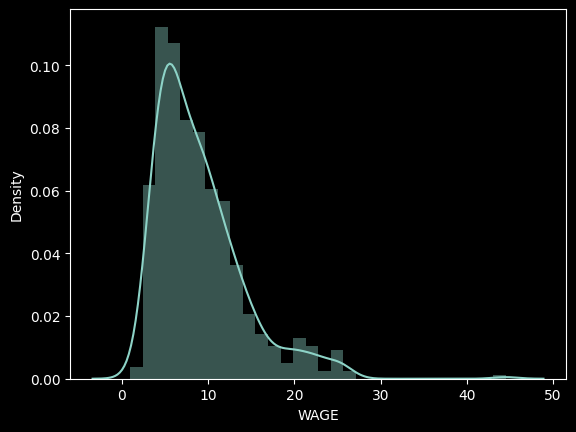

In [277]:
import seaborn as sns
display(pd.DataFrame(df['WAGE'].describe()))
sns.distplot(df['WAGE']) # 연속형 변수에.

In [278]:
eda_df1 = df.groupby('EDUCATION')['WAGE'].agg(WAGE_mean = ('mean')).reset_index()
eda_df1

,EDUCATION,WAGE_mean
0,2,3.75000
1,3,7.00000
2,4,6.00000
3,5,14.00000
4,6,4.45667
5,7,5.77000
6,8,5.97867
7,9,7.33167
8,10,7.31824
9,11,6.58444


In [279]:
eda_df1.index

RangeIndex(start=0, stop=17, step=1)

In [280]:
eda_df1.index.name

In [281]:
eda_df2 = df.groupby('OCCUPATION')['WAGE'].agg(WAGE_mean = ('mean'))
eda_df2

,WAGE_mean
OCCUPATION,
1,12.70400
2,7.59263
3,7.42258
4,6.53747
5,11.94743
6,8.42647


In [282]:
eda_df2.index

Index([1, 2, 3, 4, 5, 6], dtype='int64', name='OCCUPATION')

In [283]:
eda_df2.index.name

'OCCUPATION'

In [284]:
!pip install optbinning

In [285]:
numerical_list

['EDUCATION', 'EXPERIENCE', 'WAGE', 'AGE']

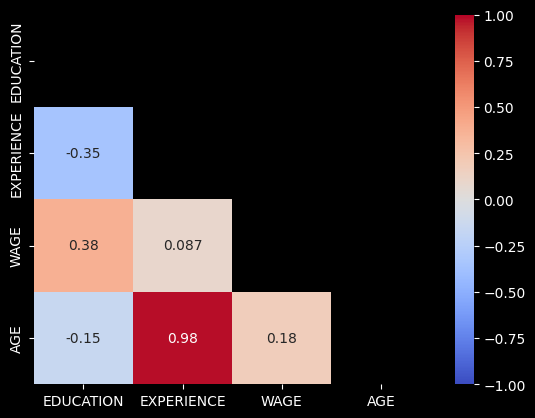

In [286]:
# ▶ heatmap plot
import seaborn as sns
# ▶ Every combination, correlation plot
df_pair = df[numerical_list] # df_pair는 df[numerical_list]를.
mask = np.triu(np.ones_like(df_pair.corr())) # #triu는 상삼각형 행렬을 만들어줌. # one_like. 
sns.heatmap(df_pair.corr(), vmin = -1, vmax = +1, annot = True, cmap = 'coolwarm', mask = mask);
# plt.gcf().set_size_inches(10, 10)

<Axes: xlabel='EDUCATION', ylabel='WAGE'>

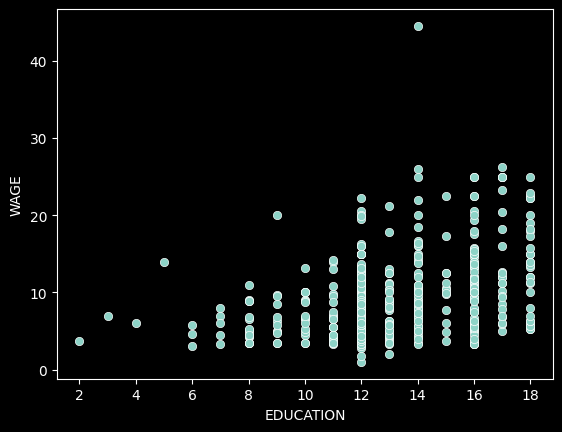

In [287]:
# 단순한 히트맵만으로는 잘 관계가 보이지 않을 때, 그래프를 그린다.
sns.scatterplot(data = df, x='EDUCATION', y='WAGE')

In [288]:
val = 'EDUCATION'
df_mart = df.copy()
quantile = df_mart[val].quantile(q=list(np.arange(0.05, 1, 0.05)), interpolation = 'nearest') # 0.05에 없으면 근접하는애에 포함해라.
quantile

0.05000     9
0.10000    10
0.15000    11
0.20000    12
0.25000    12
0.30000    12
0.35000    12
0.40000    12
0.45000    12
0.50000    12
0.55000    12
0.60000    13
0.65000    14
0.70000    14
0.75000    15
0.80000    16
0.85000    16
0.90000    17
0.95000    18
Name: EDUCATION, dtype: int64

In [289]:
# ▶ Binning
df_mart = df.copy()
val = 'EDUCATION' # 분석하고자 하는 밸류

quantile  = df_mart[val].quantile(q=list(np.arange(0.05,1,0.05)), interpolation = 'nearest') # 0.05에 없으면 근접하는애에 포함해라.
# quantile

# ▶ 그룹 초기화 
df_mart['grp'] = 0

# ▶ 40%, 75% 기준으로 총 3개 구간화 진행 - Binning
for i in  range(len(df_mart[val])) :
  if df_mart.loc[i, val] <= quantile.iloc[7] : # 40%
    df_mart.loc[i, 'grp'] = 1
  elif df_mart.loc[i, val] <= quantile.iloc[14] : # 75%
    df_mart.loc[i, 'grp'] = 2
  else : df_mart.loc[i, 'grp'] = 3

In [290]:
display(df_mart['grp'].value_counts())
display(df_mart['grp'].value_counts(normalize=True))

grp
1    302
3    126
2    106
Name: count, dtype: int64

grp
1   0.56554
3   0.23596
2   0.19850
Name: proportion, dtype: float64

In [291]:
pd.options.display.float_format = '{:.5f}'.format # Avoid e+...
df_mart.groupby('grp')['WAGE'].mean()

grp
1    7.47745
2    9.86708
3   12.02183
Name: WAGE, dtype: float64

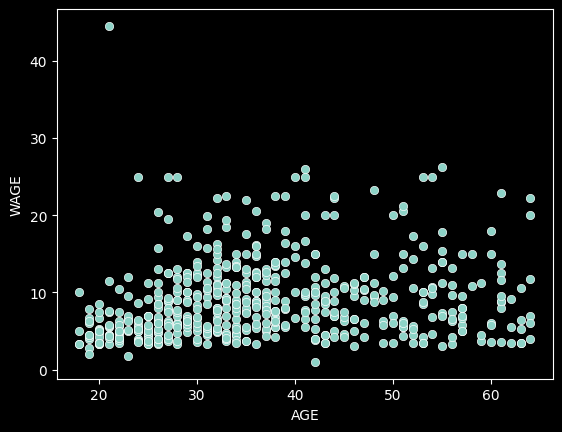

In [292]:
# ▶ scatter plot(Followers & Followers_gained)
sns.scatterplot(data = df, x='AGE', y='WAGE');

In [293]:
# ▶ Binning
df_mart = df.copy()
val = 'AGE'

quantile  = df_mart[val].quantile(q=list(np.arange(0.05,1,0.05)), interpolation = 'nearest')
# quantile

# ▶ 그룹 초기화 
df_mart['grp'] = 0

# ▶ 40%, 75% 기준으로 총 3개 구간화 진행 
for i in  range(len(df_mart[val])) :
  if df_mart.loc[i, val] <= quantile.iloc[3] : # 40%
    df_mart.loc[i, 'grp'] = 1
  elif df_mart.loc[i, val] <= quantile.iloc[14] : # 75%
    df_mart.loc[i, 'grp'] = 2
  else : df_mart.loc[i, 'grp'] = 3

In [294]:
# ▶ bin별 비중 비교
display(df_mart['grp'].value_counts())
display(df_mart['grp'].value_counts(normalize=True))

grp
2    291
3    130
1    113
Name: count, dtype: int64

grp
2   0.54494
3   0.24345
1   0.21161
Name: proportion, dtype: float64

In [295]:
quantile.iloc[3], quantile.iloc[14]

(26, 44)

In [296]:
# ▶ bin별 Target 변수와의 관계
pd.options.display.float_format = '{:.5f}'.format
df_mart.groupby('grp')['WAGE'].mean()

grp
1   6.45221
2   9.80649
3   9.50815
Name: WAGE, dtype: float64

### Categorical features

In [297]:
# South = 1, North = 0, SEX = 1, MALE = 0, UNION = 1, NON UNION = 0, RACE = 1, WHITE = 0, OCCUPATION = 0 - 6, SECTOR = 1 - 3, MARR = 0 - 1
df[categorical_list].head()


,SOUTH,SEX,UNION,RACE,OCCUPATION,SECTOR,MARR
0,0,1,0,2,6,1,1
1,0,1,0,3,6,1,1
2,0,0,0,3,6,1,0
3,0,0,0,3,6,0,0
4,0,0,0,3,6,0,1


In [298]:
meta

,value,SOUTH,SEX,UNION,RACE,OCCUPATION,SECTOR,MARR
0,0,Person lives elsewhere,Male,Not union member,NaN,NaN,Other,Unmarried
1,1,Person lives in South,Female,Union member,Other,Management,Manufacturing,Married
2,2,NaN,NaN,NaN,Hispanic,Sales,Construction,NaN
3,3,NaN,NaN,NaN,White,Clerical,NaN,NaN
4,4,NaN,NaN,NaN,NaN,Service,NaN,NaN
5,5,NaN,NaN,NaN,NaN,Professional,NaN,NaN
6,6,NaN,NaN,NaN,NaN,Other,NaN,NaN


C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_27924\3181939485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='SECTOR', kind='count', palette='Pastel1', edgecolor='.6', data=df) #count numbers by sector


,SECTOR,mean
0,0,8.87277
1,1,9.60444
2,2,9.22083


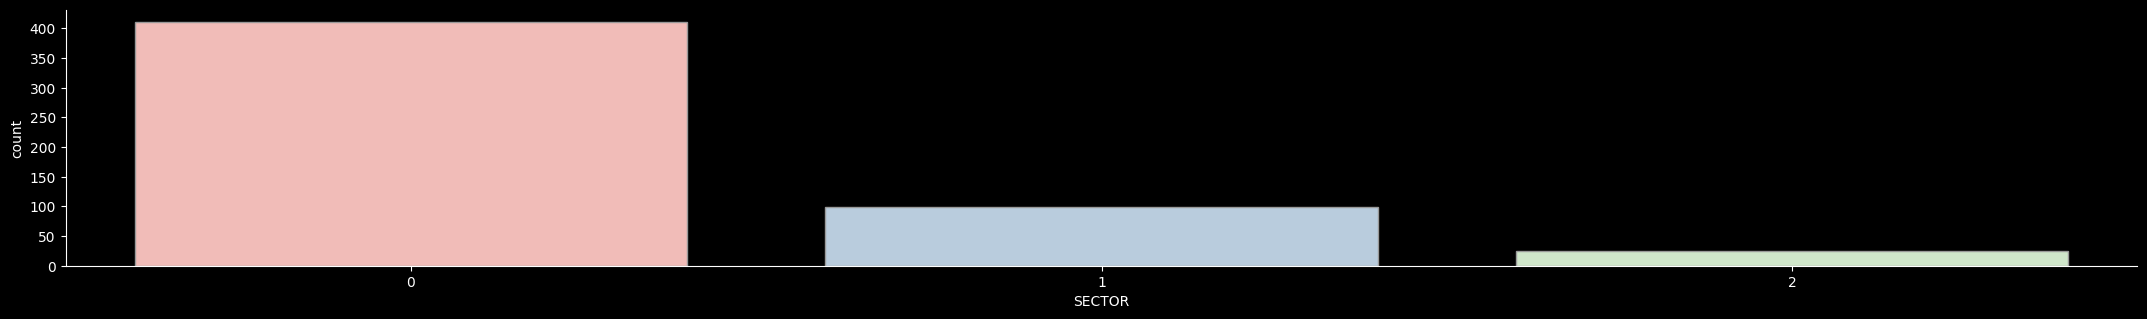

In [299]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

sns.catplot(x='SECTOR', kind='count', palette='Pastel1', edgecolor='.6', data=df) #count numbers by sector
plt.gcf().set_size_inches(25, 3)

eda_df = df.groupby('SECTOR')['WAGE'].agg(mean = ('mean')).reset_index() # groupby sector and see wage - mean value.
display(eda_df) # sector 0 = 8.8, sector1 = 9.6, sector3 = 9.2


In [300]:
from sklearn.model_selection import train_test_split

X = df.drop(['WAGE'], axis=1) # drop the target variable
y = df['WAGE']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)


(373, 10)
(373,)
(161, 10)
(161,)


In [301]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)


In [302]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(x_train_sc, y_train) # X는 scaled된 데이터, y는 원래 데이터


LinearRegression()

In [303]:
from sklearn import metrics

y_pred_train = LR.predict(x_train_sc)
y_pred_test = LR.predict(x_test_sc)

print(metrics.r2_score(y_train, y_pred_train))
print(metrics.r2_score(y_test, y_pred_test))

0.2666971723302891
0.29417772616075355


In [304]:
from sklearn.metrics import roc_auc_score

print("[Train]") 
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, y_pred_train)) #MAE
print('Mean Squared Error:', metrics.mean_squared_error(y_train, y_pred_train)) #MSE
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))) #RMSE
print('------------------------------------------')
print("[Test]")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

[Train]
Mean Absolute Error: 3.029955882174205
Mean Squared Error: 19.07265699722904
Root Mean Squared Error: 4.367225320180886
------------------------------------------
[Test]
Mean Absolute Error: 3.25379562929355
Mean Squared Error: 19.104107628262415
Root Mean Squared Error: 4.370824593627891


In [305]:
# ▶ Create a dataframe for comparing the performance of multiple models
df_comparison = pd.DataFrame(columns = ['model', 'r2_train', 'r2_test', 'RMSE_train', 'RMSE_test']) # columns cannot be a set?? 
df_comparison.columns = ['model', 'r2_train', 'r2_test', 'RMSE_train', 'RMSE_test']
df_comparison

,model,r2_train,r2_test,RMSE_train,RMSE_test


In [306]:
# ▶ LR model에 대한 성능 값 추가
import sklearn.metrics as metrics

lr_re = pd.DataFrame({ 'model' : ['LR'], # column and value
                      'r2_train' :  metrics.r2_score(y_train,y_pred_train), # 
                      'r2_test' : metrics.r2_score(y_test,y_pred_test),
                      'RMSE_train' : np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)),
                      'RMSE_test' : np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)),}
                    )

# df_comparison = df_comparison.append(lr_re) # append does not work here.
df_comparison = pd.concat([df_comparison, lr_re], ignore_index=True) # df_compration 과 lr_r2를 합친다. 
df_comparison

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_27924\2206146825.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparison = pd.concat([df_comparison, lr_re], ignore_index=True) # df_compration 과 lr_r2를 합친다.


,model,r2_train,r2_test,RMSE_train,RMSE_test
0,LR,0.26670,0.29418,4.36723,4.37082


In [307]:
# ▶ RandomForest
from sklearn.ensemble import RandomForestRegressor # 랜덤포레스트 회귀 모델

rfc = RandomForestRegressor() # 랜덤포레스트 회귀 모델
rfc.fit(x_train, y_train) # 모델 학습

# ▶ 예측 및 성능 확인
y_pred_train = rfc.predict(x_train) # 모델 예측 
y_pred_test = rfc.predict(x_test)

print(metrics.r2_score(y_train, y_pred_train))
print(metrics.r2_score(y_test, y_pred_test))

0.8605580401945483
0.18162379707927134


In [308]:
# ▶ 과적합 문제, Train과 Test set에 성능을 최대한 줄여주는 것이 과적합을 방지
from sklearn.metrics import roc_auc_score

print("[Train]")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, y_pred_train))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, y_pred_train))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print('------------------------------------------')
print("[Test]")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

[Train]
Mean Absolute Error: 1.3179861483467377
Mean Squared Error: 3.626780874202036
Root Mean Squared Error: 1.904410899517758
------------------------------------------
[Test]
Mean Absolute Error: 3.4413416149068325
Mean Squared Error: 22.150543614846452
Root Mean Squared Error: 4.706436402932313


In [309]:
# ▶ BayesianOptimization 설치
!pip install bayesian-optimization

In [310]:
# ▶ BayesianOptimization
import numpy as np
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score


def model_evaluate(n_estimators, maxDepth): # can add learning rate.
    clf = RandomForestRegressor( # learning rate is 0.1
        n_estimators= int(n_estimators),
        max_depth= int(maxDepth))
    scores = cross_val_score(clf, x_train, y_train, cv=5, scoring='r2')
    return np.mean(scores)
    
    
def bayesOpt(x_train, y_train):
    clfBO = BayesianOptimization(model_evaluate, {'n_estimators':  (100, 300), # add learning rate.
                                                  'maxDepth': (2, 6)
                                                 })
    clfBO.maximize(init_points=5, n_iter=10) # 초기 포인트 5개, 반복 10번
    print(clfBO.res)

bayesOpt(x_train, y_train)

|   iter    |  target   | maxDepth  | n_esti... |
-------------------------------------------------
| 1         | 0.1897    | 5.499     | 122.3     |
| 2         | 0.1486    | 2.754     | 195.8     |
| 3         | 0.1859    | 5.301     | 106.1     |
| 4         | 0.1704    | 5.725     | 180.1     |
| 5         | 0.1657    | 3.587     | 188.4     |
| 6         | 0.1446    | 2.27      | 134.9     |
| 7         | 0.1718    | 5.956     | 119.0     |
| 8         | 0.151     | 2.984     | 123.6     |
| 9         | 0.1722    | 5.495     | 122.5     |
| 10        | 0.1473    | 2.346     | 270.1     |
| 11        | 0.1738    | 4.888     | 250.5     |
| 12        | 0.1828    | 5.397     | 122.3     |
| 13        | 0.1848    | 5.121     | 106.1     |
| 14        | 0.1792    | 5.619     | 122.2     |
| 15        | 0.172     | 4.882     | 250.4     |
[{'target': 0.1897412102003983, 'params': {'maxDepth': 5.499126775712565, 'n_estimators': 122.34971692101234}}, {'target': 0.1485529155654194, 'params

In [311]:
# ▶ RandomForest
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics
from sklearn.metrics import roc_auc_score

rfc = RandomForestRegressor(n_estimators=300, max_depth = 2, random_state= 1121) # 
rfc.fit(x_train, y_train)

# ▶ 예측
y_pred_train = rfc.predict(x_train)
y_pred_test = rfc.predict(x_test)


rfc_re = pd.DataFrame({ 'model' : ['RFC(BO)'],
                      'r2_train' :  metrics.r2_score(y_train,y_pred_train),
                      'r2_test' : metrics.r2_score(y_test,y_pred_test),
                      'RMSE_train' : np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)),
                      'RMSE_test' : np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)),}
                    )
# rfc_re


df_comparison = pd.concat([df_comparison, rfc_re], ignore_index=True) # df_compration 과 lr_r2를 합친다. 
df_comparison

,model,r2_train,r2_test,RMSE_train,RMSE_test
0,LR,0.26670,0.29418,4.36723,4.37082
1,RFC(BO),0.26321,0.24992,4.37759,4.50577


In [312]:
# ▶ lightGBM
import lightgbm as lgbm
from lightgbm import LGBMRegressor

LGBM = lgbm.LGBMRegressor()
LGBM.fit(x_train, y_train)

LGBMRegressor()

In [313]:
# ▶ 예측
y_pred_train = LGBM.predict(x_train)
y_pred_test = LGBM.predict(x_test)

print(metrics.r2_score(y_train, y_pred_train))
print(metrics.r2_score(y_test, y_pred_test))

0.6421790014253208
0.26257900111563226


In [314]:
# ▶ AUC
print("[Train]")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, y_pred_train))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, y_pred_train))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print('------------------------------------------')
print("[Test]")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))


[Train]
Mean Absolute Error: 2.125166170143552
Mean Squared Error: 9.306656015370944
Root Mean Squared Error: 3.0506812379157124
------------------------------------------
[Test]
Mean Absolute Error: 3.2628659586494675
Mean Squared Error: 19.959373134257707
Root Mean Squared Error: 4.467591424275245


In [315]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [316]:
def lgb_evaluate(learning_rate, n_estimators, maxDepth):
    clf = LGBMRegressor(
        learning_rate= float(learning_rate),
        n_estimators= int(n_estimators),
        max_depth= int(maxDepth))
    scores = cross_val_score(clf, x_train, y_train, cv=5, scoring='r2')
    return np.mean(scores)
    
def bayesOpt(train_x, train_y):
    lgbBO = BayesianOptimization(lgb_evaluate, {'learning_rate': (0.005, 0.05),                                               
                                                'n_estimators': (100, 400),
                                                'maxDepth': (2, 6)  
                                               })
    lgbBO.maximize(init_points=5, n_iter=15)
    print(lgbBO.res)

bayesOpt(x_train, y_train)

|   iter    |  target   | learni... | maxDepth  | n_esti... |
-------------------------------------------------------------
| 1         | 0.1975    | 0.02984   | 5.694     | 367.7     |
| 2         | 0.2045    | 0.03199   | 3.412     | 395.8     |
| 3         | 0.2135    | 0.01967   | 4.247     | 272.9     |
| 4         | 0.1682    | 0.009313  | 2.964     | 155.3     |
| 5         | 0.1901    | 0.04908   | 4.557     | 317.0     |
| 6         | 0.1946    | 0.04501   | 5.89      | 241.9     |
| 7         | 0.2016    | 0.04408   | 3.852     | 269.0     |
| 8         | 0.2095    | 0.03287   | 3.374     | 278.0     |
| 9         | 0.2153    | 0.03111   | 2.164     | 385.2     |
| 10        | 0.1711    | 0.04721   | 5.95      | 379.8     |
| 11        | 0.2189    | 0.02835   | 2.271     | 388.7     |
| 12        | 0.2179    | 0.01002   | 5.996     | 390.3     |
| 13        | 0.211     | 0.02318   | 5.612     | 288.9     |
| 14        | 0.2262    | 0.03044   | 2.139     | 296.3     |
| 15    

In [319]:
# ▶ lightGBM
from lightgbm import LGBMRegressor # LightGBM

# ▶ setting the parameters
LGBM = LGBMRegressor(learning_rate=0.02, n_estimators=287, max_depth=3, random_state=1234, verbose=-1) # 287, max depth는 위의 베이지안 최적화에서 찾은 값.
LGBM.fit(x_train, y_train) # 모델 학습


# ▶ 예측
y_pred_train = LGBM.predict(x_train) #예측
y_pred_test = LGBM.predict(x_test)

lgbm_re = pd.DataFrame({ 'model' : ['LGBM(BO)3'],
                      'r2_train' :  metrics.r2_score(y_train,y_pred_train),
                      'r2_test' : metrics.r2_score(y_test,y_pred_test),
                      'RMSE_train' : np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)),
                      'RMSE_test' : np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)),}
                    )
# lgbm_re

df_comparison = pd.concat([df_comparison, lgbm_re], ignore_index=True)
df_comparison


,model,r2_train,r2_test,RMSE_train,RMSE_test
0,LR,0.26670,0.29418,4.36723,4.37082
1,RFC(BO),0.26321,0.24992,4.37759,4.50577
2,LGBM(BO)3,0.43398,0.35257,3.83688,4.18613


In [320]:
import shap
plt.style.use(['default'])

